# Fictalent · Auditoria de qualidade · financeiro, receita, títulos e impostos
<a id="topo"></a>

[Home](../../README.md) | [Auditoria](README.md) | [Entendimento dos dados](../../docs/02_entendimento_dados.md)

**Autor:** Tiago Lima
**Projeto:** rh-fictalent-bigdata · fase 6, lake (v0.6.0)
**Cliente:** Fictalent (empresa fictícia; dado sintético)
**Data:** 24/09/2026

**Objetivo:** auditar o faturamento por contrato e competência, os títulos a receber e a pagar, os impostos apurados e o consolidado gerencial, a tabela de fechamento mensal alimentada a partir das planilhas da gerência. O cliente declarou aqui o achado que considera o mais importante do projeto: o consolidado diverge da operação a partir de 2022, e a divergência cresce com o volume. É a hipótese central deste notebook.

**Base analisada:** a bronze do lake, lida pelo DuckDB com os nomes da réplica, só as linhas vivas (as marcadas como excluídas ficam de fora). Tabelas do domínio `financeiro`: `regime_tributario`, `tributo`, `aliquota`, `fornecedor`, `fatura`, `fatura_item`, `titulo_receber`, `titulo_pagar`, `imposto_apurado`, `consolidado_gerencial`.

**Regra desta auditoria: às cegas.** O notebook procura os defeitos no dado com o esquema (a DDL) e o entendimento do negócio ([`docs/02`](../../docs/02_entendimento_dados.md)) como únicas referências. Ele não consulta o gerador da base sintética nem a régua de validação, e um teste garante isso. As declarações do cliente sobre a qualidade dos próprios dados entram como **hipóteses**, testadas aqui, não como resposta.

**Perguntas-guia:**

1. A fatura fecha consigo mesma (bruto = soma dos itens, líquido = bruto menos impostos, parcelas = líquido) e com o posto que fatura?
2. O status do título bate com as datas de pagamento, e o prazo de pagamento bate com o contrato?
3. O consolidado gerencial diverge da operação (headcount, vagas, faturamento, custo)? Desde quando, e quanto? (declaração)
4. A tabela `consolidado_gerencial` da réplica e a planilha ingerida em `arquivo.consolidado_gerencial` dizem a mesma coisa?

**Sumário:**

1. [Configuração](#secao-1)
2. [A fotografia da carga](#secao-2)
3. [Perfil das colunas](#secao-3)
4. [Completude e coerência](#secao-4)
5. [Unicidade](#secao-5)
6. [Domínios declarados](#secao-6)
7. [A aritmética da fatura, do título e do imposto](#secao-7)
8. [Datas e prazos](#secao-8)
9. [Integridade referencial](#secao-9)
10. [O consolidado contra a operação](#secao-10)
11. [Fechamento](#secao-11)

<a id="secao-1"></a>

# 1. Configuração

O acesso ao dado passa pelo pacote do projeto: endereço e credencial do lake vêm do `.env`, e o notebook não conhece nenhum dos dois. Assim ele roda na máquina de qualquer pessoa com a plataforma de pé, sem editar uma linha.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

from rh_fictalent.auditoria import achados, checagens, esquema
from rh_fictalent.ingestao import marca_dagua
from rh_fictalent.lake import consulta
from rh_fictalent.orquestracao.recursos import lake_do_ambiente, warehouse_do_ambiente

RAIZ = Path.cwd().parents[1] if Path.cwd().name == "auditoria" else Path.cwd()
load_dotenv(RAIZ / ".env")

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print(f"Python {sys.version.split()[0]}")
for modulo in (pd, duckdb, matplotlib):
    print(f"{modulo.__name__:<12}{modulo.__version__}")

Python 3.12.3
pandas      3.0.5
duckdb      1.5.5
matplotlib  3.11.2


In [2]:
lake = lake_do_ambiente()
con = consulta.abrir(lake)
tabelas = esquema.do_modulo("financeiro")
nomes = [t.qualificado for t in tabelas]
registro = achados.Registro("financeiro")
print(f"{len(tabelas)} tabelas do domínio: {', '.join(t.nome for t in tabelas)}")

10 tabelas do domínio: regime_tributario, tributo, aliquota, fornecedor, fatura, fatura_item, titulo_receber, titulo_pagar, imposto_apurado, consolidado_gerencial


## Nota Técnica

**Observado:** mesma configuração; as 10 tabelas do domínio lidas da DDL.

**Por que importa:** o notebook não conhece credencial nem caminho de máquina.

**Ação:** nenhuma.

<a id="secao-2"></a>

# 2. A fotografia da carga

Toda conclusão descreve um instante. A marca d'água da ingestão diz até quando a bronze acompanha a réplica, e a contagem de linhas vivas diz o tamanho do que foi auditado. Os dois são lidos, não digitados, para não envelhecerem.

In [3]:
marcas = marca_dagua.ler(warehouse_do_ambiente())
do_dominio = {n: marcas[n] for n in nomes if n in marcas}
REFERENCIA = max(m.marca for m in do_dominio.values())
HOJE = REFERENCIA.date()
print(f"Marca d'água mais recente do domínio: {REFERENCIA:%d/%m/%Y %H:%M}")
print(f"Data de referência das regras com prazo (\"hoje\" do dado): {HOJE:%d/%m/%Y}")

volume = pd.DataFrame(
    [{"tabela": n, "linhas_vivas": checagens.linhas(con, n), "marca": do_dominio[n].marca if n in do_dominio else None} for n in nomes]
)
TOTAL = int(volume["linhas_vivas"].sum())
print(f"Linhas vivas no domínio: {TOTAL:,}".replace(",", "."))
volume

Marca d'água mais recente do domínio: 24/09/2026 15:02
Data de referência das regras com prazo ("hoje" do dado): 24/09/2026
Linhas vivas no domínio: 18.758


,tabela,linhas_vivas,marca
0,financeiro.regime_tributario,1,2026-09-24 15:02:06.227515
1,financeiro.tributo,5,2026-09-24 15:02:06.227515
2,financeiro.aliquota,7,2026-09-24 15:02:06.227515
3,financeiro.fornecedor,9,2026-09-24 15:02:06.227515
4,financeiro.fatura,3459,2026-09-24 15:02:06.227515
5,financeiro.fatura_item,9116,2026-09-24 15:02:06.227515
6,financeiro.titulo_receber,3459,2026-09-24 15:02:06.227515
7,financeiro.titulo_pagar,1952,2026-09-24 15:02:06.227515
8,financeiro.imposto_apurado,513,2026-09-24 15:02:06.227515
9,financeiro.consolidado_gerencial,237,2026-09-24 15:02:06.227515


## Nota Técnica

**Observado:** 18.758 linhas vivas: 3.459 faturas com 9.116 itens e 3.459 títulos a receber (uma parcela por fatura), 1.952 títulos a pagar, 513 impostos apurados, 9 fornecedores, 5 tributos com 7 alíquotas, um regime tributário, e as 237 linhas do consolidado gerencial (uma por filial e mês).

**Por que importa:** é o domínio da receita e da margem, e é onde mora a declaração que o cliente considera a mais importante: o consolidado que diverge da operação.

**Ação:** nenhuma.

<a id="secao-3"></a>

# 3. Perfil das colunas

Antes de procurar defeito é preciso saber o que há. Uma linha por coluna: tipo, nulos, distintos, mínimo e máximo. É o mapa que orienta as seções seguintes: coluna toda nula, coluna com um valor só, data fora do arco.

In [4]:
perfis = pd.concat([checagens.perfil(con, n) for n in nomes], ignore_index=True)
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0) & (perfis["tipo"] != "BOOLEAN")]
vazias = perfis[perfis["pct_nulo"] >= 100]
print(f"{len(perfis)} colunas em {len(nomes)} tabelas")
print(f"Colunas com um valor só: {len(constantes)}" + (f" ({', '.join(constantes['tabela'] + '.' + constantes['coluna'])})" if len(constantes) else ""))
print(f"Colunas totalmente vazias: {len(vazias)}" + (f" ({', '.join(vazias['tabela'] + '.' + vazias['coluna'])})" if len(vazias) else ""))
perfis

93 colunas em 10 tabelas
Colunas com um valor só: 14 (financeiro.regime_tributario.id, financeiro.regime_tributario.regime, financeiro.regime_tributario.vigencia_inicio, financeiro.regime_tributario.criado_em, financeiro.regime_tributario.atualizado_em, financeiro.tributo.criado_em, financeiro.tributo.atualizado_em, financeiro.aliquota.vigencia_inicio, financeiro.aliquota.criado_em, financeiro.aliquota.atualizado_em, financeiro.fornecedor.criado_em, financeiro.fornecedor.atualizado_em, financeiro.titulo_receber.numero_parcela, financeiro.consolidado_gerencial.origem)
Colunas totalmente vazias: 2 (financeiro.regime_tributario.vigencia_fim, financeiro.aliquota.vigencia_fim)


,tabela,coluna,tipo,nulos,pct_nulo,distintos,minimo,maximo
0,financeiro.regime_tributario,id,BIGINT,0,0.00,1,1,1
1,financeiro.regime_tributario,regime,VARCHAR,0,0.00,1,LUCRO_PRESUMIDO,LUCRO_PRESUMIDO
2,financeiro.regime_tributario,vigencia_inicio,DATE,0,0.00,1,2018-01-01,2018-01-01
3,financeiro.regime_tributario,vigencia_fim,DATE,1,100.00,0,NaN,NaN
4,financeiro.regime_tributario,criado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00
5,financeiro.regime_tributario,atualizado_em,TIMESTAMP,0,0.00,1,2018-01-02 08:00:00,2018-01-02 08:00:00
6,financeiro.tributo,id,BIGINT,0,0.00,5,1,5
7,financeiro.tributo,codigo,VARCHAR,0,0.00,5,COFINS,PIS
8,financeiro.tributo,descricao,VARCHAR,0,0.00,5,COFINS cumulativa,PIS cumulativo
9,financeiro.tributo,esfera,VARCHAR,0,0.00,2,FEDERAL,MUNICIPAL


In [5]:
# a bronze promete ser espelho da réplica também no tipo: um inteiro copiado como booleano vira True em toda linha, e nenhuma contagem acusa
tipos = pd.concat([checagens.tipos(con, t) for t in tabelas], ignore_index=True)
incompativeis = tipos[~tipos["compativel"]]
print(f"{len(tipos)} colunas com o tipo conferido contra a DDL; incompatíveis: {len(incompativeis)}")
incompativeis

93 colunas com o tipo conferido contra a DDL; incompatíveis: 0


,tabela,coluna,ddl,bronze,compativel


## Nota Técnica

**Observado:** 93 colunas, tipos compatíveis com a DDL. Catorze constantes e duas vazias, todas por regra: um regime tributário só (lucro presumido, vigência aberta), alíquotas com vigência aberta desde o início, toda fatura em parcela única e o consolidado sempre de origem `PLANILHA`.

**Por que importa:** regime e alíquota únicos simplificam a conferência do imposto (seção 7); a parcela única simplifica a do título.

**Ação:** nenhuma.

<a id="secao-4"></a>

# 4. Completude e coerência

Título pago tem data e valor pago; título aberto não tem; fatura quitada não tem parcela em aberto; imposto apurado gera título a pagar; o tipo do título combina com o tipo do fornecedor.

In [6]:
obrigatorias = {(t.qualificado, c.nome) for t in tabelas for c in t.colunas if not c.nulo}
com_nulos = perfis[perfis["nulos"] > 0].sort_values("pct_nulo", ascending=False)
com_nulos = com_nulos.assign(obrigatoria=[(t, c) in obrigatorias for t, c in zip(com_nulos["tabela"], com_nulos["coluna"])])
print(f"Colunas com algum nulo: {len(com_nulos)}; delas, declaradas NOT NULL: {int(com_nulos['obrigatoria'].sum())}")
com_nulos[["tabela", "coluna", "tipo", "nulos", "pct_nulo", "obrigatoria"]]

Colunas com algum nulo: 9; delas, declaradas NOT NULL: 0


,tabela,coluna,tipo,nulos,pct_nulo,obrigatoria
3,financeiro.regime_tributario,vigencia_fim,DATE,1,100.00,False
18,financeiro.aliquota,vigencia_fim,DATE,7,100.00,False
16,financeiro.aliquota,base_presumida_pct,"DECIMAL(7,4)",5,71.43,False
14,financeiro.aliquota,municipio_id,BIGINT,4,57.14,False
63,financeiro.titulo_pagar,fornecedor_id,BIGINT,1091,55.89,False
75,financeiro.imposto_apurado,municipio_id,BIGINT,276,53.80,False
57,financeiro.titulo_receber,dt_pagamento,DATE,121,3.50,False
58,financeiro.titulo_receber,valor_pago,"DECIMAL(14,2)",121,3.50,False
69,financeiro.titulo_pagar,dt_pagamento,DATE,5,0.26,False


In [7]:
coerencia = consulta.sql(con, '''
    SELECT 'titulo_receber PAGO sem dt_pagamento' AS caso, count(*) AS linhas FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND status = 'PAGO' AND dt_pagamento IS NULL
    UNION ALL SELECT 'titulo_receber PAGO sem valor_pago', count(*) FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND status = 'PAGO' AND valor_pago IS NULL
    UNION ALL SELECT 'titulo_receber ABERTO/ATRASADO com dt_pagamento', count(*) FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND status IN ('ABERTO', 'ATRASADO') AND dt_pagamento IS NOT NULL
    UNION ALL SELECT 'titulo_receber ABERTO com vencimento passado (deveria ser ATRASADO)', count(*) FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND status = 'ABERTO' AND dt_vencimento < ?
    UNION ALL SELECT 'titulo_receber ATRASADO com vencimento futuro', count(*) FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND status = 'ATRASADO' AND dt_vencimento >= ?
    UNION ALL SELECT 'titulo_pagar PAGO sem dt_pagamento', count(*) FROM financeiro.titulo_pagar WHERE excluido_em IS NULL AND status = 'PAGO' AND dt_pagamento IS NULL
    UNION ALL SELECT 'titulo_pagar ABERTO/ATRASADO com dt_pagamento', count(*) FROM financeiro.titulo_pagar WHERE excluido_em IS NULL AND status IN ('ABERTO', 'ATRASADO') AND dt_pagamento IS NOT NULL
    UNION ALL SELECT 'titulo_pagar FORNECEDOR sem fornecedor', count(*) FROM financeiro.titulo_pagar WHERE excluido_em IS NULL AND tipo = 'FORNECEDOR' AND fornecedor_id IS NULL
    UNION ALL SELECT 'titulo_pagar FOLHA/ENCARGOS/IMPOSTOS com fornecedor', count(*) FROM financeiro.titulo_pagar WHERE excluido_em IS NULL AND tipo IN ('FOLHA', 'ENCARGOS', 'IMPOSTOS') AND fornecedor_id IS NOT NULL
    UNION ALL SELECT 'titulo_pagar BENEFICIOS com fornecedor que nao e de BENEFICIOS', count(*) FROM financeiro.titulo_pagar t JOIN financeiro.fornecedor f ON f.id = t.fornecedor_id WHERE t.excluido_em IS NULL AND t.tipo = 'BENEFICIOS' AND f.tipo <> 'BENEFICIOS'
    UNION ALL SELECT 'fatura QUITADA com parcela nao PAGA', count(DISTINCT f.id) FROM financeiro.fatura f JOIN financeiro.titulo_receber t ON t.fatura_id = f.id AND t.excluido_em IS NULL WHERE f.excluido_em IS NULL AND f.status = 'QUITADA' AND t.status <> 'PAGO'
    UNION ALL SELECT 'fatura EM_ABERTO com todas as parcelas PAGAS', count(*) FROM financeiro.fatura f WHERE f.excluido_em IS NULL AND f.status = 'EM_ABERTO' AND NOT EXISTS (SELECT 1 FROM financeiro.titulo_receber t WHERE t.excluido_em IS NULL AND t.fatura_id = f.id AND t.status <> 'PAGO')
    UNION ALL SELECT 'fatura CANCELADA com parcela PAGA', count(DISTINCT f.id) FROM financeiro.fatura f JOIN financeiro.titulo_receber t ON t.fatura_id = f.id AND t.excluido_em IS NULL WHERE f.excluido_em IS NULL AND f.status = 'CANCELADA' AND t.status = 'PAGO'
    UNION ALL SELECT 'fatura sem nenhum titulo', count(*) FROM financeiro.fatura f WHERE f.excluido_em IS NULL AND f.status <> 'CANCELADA' AND NOT EXISTS (SELECT 1 FROM financeiro.titulo_receber t WHERE t.excluido_em IS NULL AND t.fatura_id = f.id)
    UNION ALL SELECT 'fatura sem nenhum item', count(*) FROM financeiro.fatura f WHERE f.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM financeiro.fatura_item i WHERE i.excluido_em IS NULL AND i.fatura_id = f.id)
    UNION ALL SELECT 'imposto_apurado sem titulo_pagar', count(*) FROM financeiro.imposto_apurado WHERE excluido_em IS NULL AND titulo_pagar_id IS NULL
    UNION ALL SELECT 'aliquota de tributo MUNICIPAL sem municipio', count(*) FROM financeiro.aliquota a JOIN financeiro.tributo t ON t.id = a.tributo_id WHERE a.excluido_em IS NULL AND t.esfera = 'MUNICIPAL' AND a.municipio_id IS NULL
    UNION ALL SELECT 'regime tributario sem vigencia aberta hoje', count(*) FROM (SELECT 1 WHERE NOT EXISTS (SELECT 1 FROM financeiro.regime_tributario WHERE excluido_em IS NULL AND vigencia_inicio <= ? AND coalesce(vigencia_fim, DATE '9999-12-31') >= ?))
''', HOJE, HOJE, HOJE, HOJE)
print(f"Testes de coerência: {len(coerencia)}; com linhas: {int((coerencia['linhas'] > 0).sum())}")
print(coerencia.to_string(index=False))
sem_item = consulta.sql(con, "SELECT k.tipo_servico, count(*) AS faturas_sem_item FROM financeiro.fatura f JOIN comercial.contrato k ON k.id = f.contrato_id WHERE f.excluido_em IS NULL AND NOT EXISTS (SELECT 1 FROM financeiro.fatura_item i WHERE i.excluido_em IS NULL AND i.fatura_id = f.id) GROUP BY 1")
print(); print(sem_item.to_string(index=False))
n_titulos = checagens.linhas(con, "financeiro.titulo_receber")
n_faturas = checagens.linhas(con, "financeiro.fatura")
abertos_vencidos = int(coerencia.loc[coerencia["caso"].str.startswith("titulo_receber ABERTO com vencimento"), "linhas"].iloc[0])
registro.anotar(
    secao="4", tabela="financeiro.titulo_receber", coluna="status, dt_vencimento",
    achado="título a receber ABERTO com vencimento passado, que deveria estar ATRASADO", linhas=abertos_vencidos, total=n_titulos, severidade="baixa",
    impacto="inadimplência escondida do indicador de atraso", acao="a silver deriva a situação do título das datas e preserva o status original",
)
registro.anotar(
    secao="4", tabela="financeiro.fatura", coluna="id (sem item)",
    achado="faturas sem item: todas de contratos de recrutamento, que faturam honorário por colocação e não posto por mês (regra, não defeito)", linhas=0, total=n_faturas, severidade="nenhuma",
    impacto="a fatura de honorário não tem posto; a gold trata os dois negócios separados", acao="nenhuma",
)
print(f"anotados: {len(registro)}")

Testes de coerência: 18; com linhas: 2
                                                               caso  linhas
                               titulo_receber PAGO sem dt_pagamento       0
                                 titulo_receber PAGO sem valor_pago       0
                    titulo_receber ABERTO/ATRASADO com dt_pagamento       0
titulo_receber ABERTO com vencimento passado (deveria ser ATRASADO)       5
                      titulo_receber ATRASADO com vencimento futuro       0
                                 titulo_pagar PAGO sem dt_pagamento       0
                      titulo_pagar ABERTO/ATRASADO com dt_pagamento       0
                             titulo_pagar FORNECEDOR sem fornecedor       0
                titulo_pagar FOLHA/ENCARGOS/IMPOSTOS com fornecedor       0
     titulo_pagar BENEFICIOS com fornecedor que nao e de BENEFICIOS       0
                                fatura QUITADA com parcela nao PAGA       0
                       fatura EM_ABERTO com todas

## Nota Técnica

**Observado:** 9 colunas com nulo, nenhuma `NOT NULL`. Dos 18 testes de coerência, 16 passaram (título pago sempre com data e valor, fatura quitada sem parcela em aberto, imposto sempre com título a pagar, alíquota municipal sempre com município, o tipo do título coerente com o tipo do fornecedor). Dois não: **5 títulos a receber `ABERTO` com vencimento passado, que deveriam estar `ATRASADO`**, e 818 faturas sem item, que são todas as faturas de contratos de recrutamento: honorário por colocação, não posto por mês, e portanto regra, não defeito.

**Por que importa:** o status desatualizado do título esconde inadimplência do indicador de atraso; a fatura de honorário sem item é a diferença entre os dois negócios da Fictalent.

**Ação:** anotar o título aberto vencido como baixa (a silver deriva a situação do título das datas) e a fatura de honorário como regra, com severidade `nenhuma`.

<a id="secao-5"></a>

# 5. Unicidade

Número de fatura, parcela por fatura, CNPJ de fornecedor, código de tributo e competência por filial do consolidado são `UNIQUE`. A duplicidade de conteúdo: duas faturas para o mesmo contrato na mesma competência, o mesmo posto duas vezes na mesma fatura, o mesmo imposto apurado duas vezes.

In [8]:
linhas_unicas = []
for t in tabelas:
    for chave in t.unicas:
        grupos, envolvidas = checagens.repetidos(con, t.qualificado, list(chave))
        linhas_unicas.append({"tabela": t.qualificado, "chave": ", ".join(chave), "grupos_repetidos": grupos, "linhas": envolvidas})
unicas = pd.DataFrame(linhas_unicas)
print(f"{len(unicas)} chaves UNIQUE conferidas; com repetição: {int((unicas['grupos_repetidos'] > 0).sum())}")
print(unicas.to_string(index=False))
print()
for tabela, colunas, descricao in (
    ("financeiro.fatura", ["contrato_id", "competencia"], "duas faturas para o mesmo contrato e competencia"),
    ("financeiro.fatura_item", ["fatura_id", "posto_id"], "o mesmo posto duas vezes na fatura"),
    ("financeiro.imposto_apurado", ["competencia", "tributo_id", "municipio_id"], "o mesmo imposto apurado duas vezes"),
    ("financeiro.titulo_pagar", ["tipo", "centro_custo_id", "competencia", "fornecedor_id"], "o mesmo titulo a pagar duas vezes"),
    ("financeiro.fornecedor", ["razao_social"], "o mesmo fornecedor com dois CNPJs (grafia normalizada)"),
):
    grupos, envolvidas = checagens.repetidos(con, tabela, colunas, normalizar=True)
    print(f"{tabela:<28} {'+'.join(colunas):<48} {grupos:>5} grupos  {envolvidas:>6} linhas   ({descricao})")
cnpj_linhas, _ = checagens.documentos_invalidos(con, "financeiro.fornecedor", "cnpj", checagens.cnpj_valido)
print(f"\nfornecedor com CNPJ inválido pelo dígito: {cnpj_linhas}")
print(f"aliquota: vigências cruzadas do mesmo tributo e município: {checagens.sobreposicoes(con, 'financeiro.aliquota', ['tributo_id', 'municipio_id'], 'vigencia_inicio', 'vigencia_fim')}")
print(f"regime_tributario: vigências cruzadas: {checagens.sobreposicoes(con, 'financeiro.regime_tributario', 'regime', 'vigencia_inicio', 'vigencia_fim')}")

5 chaves UNIQUE conferidas; com repetição: 0
                          tabela                     chave  grupos_repetidos  linhas
              financeiro.tributo                    codigo                 0       0
           financeiro.fornecedor                      cnpj                 0       0
               financeiro.fatura                    numero                 0       0
       financeiro.titulo_receber fatura_id, numero_parcela                 0       0
financeiro.consolidado_gerencial    competencia, filial_id                 0       0



financeiro.fatura            contrato_id+competencia                              0 grupos       0 linhas   (duas faturas para o mesmo contrato e competencia)
financeiro.fatura_item       fatura_id+posto_id                                   0 grupos       0 linhas   (o mesmo posto duas vezes na fatura)
financeiro.imposto_apurado   competencia+tributo_id+municipio_id                  0 grupos       0 linhas   (o mesmo imposto apurado duas vezes)
financeiro.titulo_pagar      tipo+centro_custo_id+competencia+fornecedor_id       0 grupos       0 linhas   (o mesmo titulo a pagar duas vezes)
financeiro.fornecedor        razao_social                                         0 grupos       0 linhas   (o mesmo fornecedor com dois CNPJs (grafia normalizada))

fornecedor com CNPJ inválido pelo dígito: 0
aliquota: vigências cruzadas do mesmo tributo e município: 0
regime_tributario: vigências cruzadas: 0


## Nota Técnica

**Observado:** as 5 chaves `UNIQUE` íntegras, nenhuma fatura, item, imposto, título a pagar ou fornecedor duplicado por conteúdo, todos os CNPJs de fornecedor válidos, nenhuma alíquota ou regime com vigências cruzadas.

**Por que importa:** cada contrato tem uma fatura por competência e cada posto um item por fatura.

**Ação:** nenhuma.

<a id="secao-6"></a>

# 6. Domínios declarados

Os domínios em `CHECK` e a distribuição dentro deles.

In [9]:
dominios = pd.concat([checagens.dominios(con, t) for t in tabelas], ignore_index=True)
print(f"{len(dominios)} domínios conferidos; com valor fora: {int((dominios['fora'] > 0).sum())}")
display(dominios)
for tabela, coluna in (("financeiro.fatura", "status"), ("financeiro.titulo_receber", "status"), ("financeiro.titulo_pagar", "tipo"), ("financeiro.titulo_pagar", "status"), ("financeiro.fornecedor", "tipo"), ("financeiro.tributo", "esfera")):
    print(f"{tabela}.{coluna}: " + ", ".join(f"{v}={n}" for v, n in con.execute(f"SELECT {coluna}, count(*) FROM {tabela} WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 2 DESC").fetchall()))

8 domínios conferidos; com valor fora: 0


,tabela,coluna,esperados,fora,exemplos
0,financeiro.regime_tributario,regime,2,0,
1,financeiro.tributo,esfera,3,0,
2,financeiro.fornecedor,tipo,4,0,
3,financeiro.fatura,status,4,0,
4,financeiro.titulo_receber,status,4,0,
5,financeiro.titulo_pagar,tipo,5,0,
6,financeiro.titulo_pagar,status,4,0,
7,financeiro.consolidado_gerencial,origem,1,0,


financeiro.fatura.status: QUITADA=3338, EM_ABERTO=71, EMITIDA=50
financeiro.titulo_receber.status: PAGO=3338, ATRASADO=71, ABERTO=50
financeiro.titulo_pagar.tipo: FORNECEDOR=624, IMPOSTOS=513, FOLHA=341, BENEFICIOS=237, ENCARGOS=237
financeiro.titulo_pagar.status: PAGO=1947, ABERTO=5
financeiro.fornecedor.tipo: SERVICOS=5, EXAMES=2, TREINAMENTO=1, BENEFICIOS=1
financeiro.tributo.esfera: FEDERAL=4, MUNICIPAL=1


## Nota Técnica

**Observado:** os 8 domínios só têm valores previstos.

**Por que importa:** status de fatura e de título entram direto como dimensão.

**Ação:** nenhuma.

<a id="secao-7"></a>

# 7. A aritmética da fatura, do título e do imposto

Bruto igual à soma dos itens; líquido igual a bruto menos impostos; item igual a postos mais extras menos descontos; parcelas iguais ao líquido; valor pago contra o valor do título; imposto devido igual a base vezes alíquota, e a alíquota da apuração contra a tabela. E a fatura contra a operação: o item fatura um posto do contrato, vigente na competência?

In [10]:
aritmetica = consulta.sql(con, '''
    WITH itens AS (SELECT fatura_id, sum(valor_total) AS soma FROM financeiro.fatura_item WHERE excluido_em IS NULL GROUP BY 1),
         parcelas AS (SELECT fatura_id, sum(valor) AS soma FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND status <> 'CANCELADO' GROUP BY 1)
    SELECT 'fatura com item: bruto <> soma dos itens' AS caso, count(*) AS linhas FROM financeiro.fatura f JOIN itens i ON i.fatura_id = f.id WHERE f.excluido_em IS NULL AND abs(f.valor_bruto - i.soma) > 0.01
    UNION ALL SELECT 'fatura: liquido <> bruto - impostos', count(*) FROM financeiro.fatura WHERE excluido_em IS NULL AND abs(valor_liquido - (valor_bruto - valor_impostos)) > 0.01
    UNION ALL SELECT 'fatura: impostos fora de 0..30% do bruto', count(*) FROM financeiro.fatura WHERE excluido_em IS NULL AND valor_bruto > 0 AND (valor_impostos < 0 OR valor_impostos > 0.30 * valor_bruto)
    UNION ALL SELECT 'fatura nao cancelada: parcelas <> liquido', count(*) FROM financeiro.fatura f LEFT JOIN parcelas p ON p.fatura_id = f.id WHERE f.excluido_em IS NULL AND f.status <> 'CANCELADA' AND abs(f.valor_liquido - coalesce(p.soma, 0)) > 0.01
    UNION ALL SELECT 'item: total <> postos + extras - descontos', count(*) FROM financeiro.fatura_item WHERE excluido_em IS NULL AND abs(valor_total - (valor_postos + valor_horas_extras - valor_descontos)) > 0.01
    UNION ALL SELECT 'item: dias trabalhados acima de vagas do posto x 31', count(*) FROM financeiro.fatura_item i JOIN comercial.posto p ON p.id = i.posto_id WHERE i.excluido_em IS NULL AND i.qtd_dias_trabalhados > p.quantidade * 31
    UNION ALL SELECT 'item: dias trabalhados + faltas acima de vagas x 31', count(*) FROM financeiro.fatura_item i JOIN comercial.posto p ON p.id = i.posto_id WHERE i.excluido_em IS NULL AND i.qtd_dias_trabalhados + i.qtd_faltas > p.quantidade * 31
    UNION ALL SELECT 'item: valor_total <= 0', count(*) FROM financeiro.fatura_item WHERE excluido_em IS NULL AND valor_total <= 0
    UNION ALL SELECT 'titulo_receber PAGO: valor_pago <> valor', count(*) FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND status = 'PAGO' AND abs(valor_pago - valor) > 0.01
    UNION ALL SELECT 'titulo: valor <= 0 (receber e pagar)', (SELECT count(*) FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND valor <= 0) + (SELECT count(*) FROM financeiro.titulo_pagar WHERE excluido_em IS NULL AND valor <= 0)
    UNION ALL SELECT 'imposto: devido <> base x aliquota apurada (tolerancia R$ 0,02)', count(*) FROM financeiro.imposto_apurado WHERE excluido_em IS NULL AND abs(valor_devido - base_calculo * aliquota) > 0.02
    UNION ALL SELECT 'imposto: aliquota apurada <> aliquota da tabela', count(*) FROM financeiro.imposto_apurado i JOIN financeiro.aliquota a ON a.tributo_id = i.tributo_id AND coalesce(a.municipio_id, 0) = coalesce(i.municipio_id, 0) AND i.competencia BETWEEN a.vigencia_inicio AND coalesce(a.vigencia_fim, DATE '9999-12-31') AND a.excluido_em IS NULL WHERE i.excluido_em IS NULL AND abs(i.aliquota - a.aliquota) > 0.0001
    UNION ALL SELECT 'imposto com titulo_pagar de valor diferente', count(*) FROM financeiro.imposto_apurado i JOIN financeiro.titulo_pagar t ON t.id = i.titulo_pagar_id WHERE i.excluido_em IS NULL AND abs(i.valor_devido - t.valor) > 0.01
''')
print(f"Regras conferidas: {len(aritmetica)}; com linhas: {int((aritmetica['linhas'] > 0).sum())}")
print(aritmetica.to_string(index=False))
irpj = consulta.sql(con, '''
    SELECT tr.codigo, count(*) AS apuracoes, round(min(i.aliquota), 4) AS aliquota_efetiva_min, round(max(i.aliquota), 4) AS aliquota_efetiva_max, round(max(a.aliquota), 4) AS aliquota_da_tabela, round(max(abs(i.valor_devido - i.base_calculo * i.aliquota)), 2) AS maior_diferenca_reais
    FROM financeiro.imposto_apurado i JOIN financeiro.tributo tr ON tr.id = i.tributo_id JOIN financeiro.aliquota a ON a.tributo_id = i.tributo_id AND coalesce(a.municipio_id, 0) = coalesce(i.municipio_id, 0) AND i.competencia BETWEEN a.vigencia_inicio AND coalesce(a.vigencia_fim, DATE '9999-12-31')
    WHERE i.excluido_em IS NULL AND abs(i.aliquota - a.aliquota) > 0.0001 GROUP BY 1''')
print(); print(irpj.to_string(index=False))

Regras conferidas: 13; com linhas: 4
                                                           caso  linhas
                       fatura com item: bruto <> soma dos itens       0
                            fatura: liquido <> bruto - impostos       0
                       fatura: impostos fora de 0..30% do bruto       0
                      fatura nao cancelada: parcelas <> liquido       0
                     item: total <> postos + extras - descontos       1
            item: dias trabalhados acima de vagas do posto x 31       0
            item: dias trabalhados + faltas acima de vagas x 31       0
                                         item: valor_total <= 0       0
                       titulo_receber PAGO: valor_pago <> valor      37
                           titulo: valor <= 0 (receber e pagar)       0
imposto: devido <> base x aliquota apurada (tolerancia R$ 0,02)      34
                imposto: aliquota apurada <> aliquota da tabela      34
                    imposto

In [11]:
operacao = consulta.sql(con, '''
    SELECT 'item de posto que nao e do contrato da fatura' AS caso, count(*) AS linhas FROM financeiro.fatura_item i JOIN financeiro.fatura f ON f.id = i.fatura_id JOIN comercial.posto p ON p.id = i.posto_id WHERE i.excluido_em IS NULL AND p.contrato_id <> f.contrato_id
    UNION ALL SELECT 'item de posto nao vigente na competencia', count(*) FROM financeiro.fatura_item i JOIN financeiro.fatura f ON f.id = i.fatura_id JOIN comercial.posto p ON p.id = i.posto_id WHERE i.excluido_em IS NULL AND (p.vigencia_inicio > last_day(f.competencia) OR coalesce(p.vigencia_fim, DATE '9999-12-31') < f.competencia)
    UNION ALL SELECT 'fatura de competencia posterior ao encerramento do contrato', count(*) FROM financeiro.fatura f JOIN comercial.contrato k ON k.id = f.contrato_id WHERE f.excluido_em IS NULL AND k.dt_encerramento IS NOT NULL AND f.competencia > k.dt_encerramento
    UNION ALL SELECT 'fatura de competencia anterior ao inicio do contrato', count(*) FROM financeiro.fatura f JOIN comercial.contrato k ON k.id = f.contrato_id WHERE f.excluido_em IS NULL AND last_day(f.competencia) < k.vigencia_inicio
    UNION ALL SELECT 'fatura de cliente diferente do cliente do contrato', count(*) FROM financeiro.fatura f JOIN comercial.contrato k ON k.id = f.contrato_id WHERE f.excluido_em IS NULL AND k.cliente_id <> f.cliente_id
    UNION ALL SELECT 'titulo_receber de cliente diferente do da fatura', count(*) FROM financeiro.titulo_receber t JOIN financeiro.fatura f ON f.id = t.fatura_id WHERE t.excluido_em IS NULL AND t.cliente_id <> f.cliente_id
    UNION ALL SELECT 'posto com alocacao no mes e sem item de fatura (meses ja fechados)', count(*) FROM (
        SELECT DISTINCT date_trunc('month', a.dt_inicio) AS m, a.posto_id FROM pessoas.alocacao a WHERE a.excluido_em IS NULL) x
      WHERE x.m < date_trunc('month', ?::DATE) AND NOT EXISTS (SELECT 1 FROM financeiro.fatura_item i JOIN financeiro.fatura f ON f.id = i.fatura_id WHERE i.excluido_em IS NULL AND i.posto_id = x.posto_id AND f.competencia = x.m)
''', HOJE)
print(operacao.to_string(index=False))
pos = consulta.sql(con, "SELECT count(*) AS faturas, min(date_diff('day', k.dt_encerramento, f.competencia)) AS dias_depois_min, max(date_diff('day', k.dt_encerramento, f.competencia)) AS dias_depois_max FROM financeiro.fatura f JOIN comercial.contrato k ON k.id = f.contrato_id WHERE f.excluido_em IS NULL AND k.dt_encerramento IS NOT NULL AND f.competencia > k.dt_encerramento")
print(pos.to_string(index=False))
pagos = consulta.sql(con, "SELECT count(*) AS titulos, count(*) FILTER (WHERE valor_pago < valor) AS pagos_a_menos, count(*) FILTER (WHERE valor_pago > valor) AS pagos_a_mais, round(median(valor_pago / valor), 3) AS razao_mediana FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND status = 'PAGO' AND abs(valor_pago - valor) > 0.01")
print(pagos.to_string(index=False))

                                                              caso  linhas
                     item de posto que nao e do contrato da fatura       0
                          item de posto nao vigente na competencia       0
       fatura de competencia posterior ao encerramento do contrato      42
              fatura de competencia anterior ao inicio do contrato       0
                fatura de cliente diferente do cliente do contrato       0
                  titulo_receber de cliente diferente do da fatura       0
posto com alocacao no mes e sem item de fatura (meses ja fechados)       4
 faturas  dias_depois_min  dias_depois_max
      42                5              149
 titulos  pagos_a_menos  pagos_a_mais  razao_mediana
      37             29             8           0.97


In [12]:
n_itens = checagens.linhas(con, "financeiro.fatura_item")
n_impostos = checagens.linhas(con, "financeiro.imposto_apurado")
posto_mes_alocado = checagens.contar(con, "SELECT count(*) FROM (SELECT DISTINCT date_trunc('month', a.dt_inicio) AS m, a.posto_id FROM pessoas.alocacao a WHERE a.excluido_em IS NULL) x WHERE x.m < date_trunc('month', ?::DATE)", HOJE)
registro.anotar(
    secao="7", tabela="financeiro.fatura", coluna="competencia, contrato.dt_encerramento",
    achado="fatura de competência posterior ao encerramento do contrato", linhas=int(pos.iloc[0]["faturas"]), total=n_faturas, severidade="media",
    impacto="receita reconhecida em contrato que não existe mais, ou encerramento lançado com data errada",
    acao="a silver marca; o cliente diz qual data está certa",
)
registro.anotar(
    secao="7", tabela="financeiro.fatura_item", coluna="posto_id, competencia",
    achado="posto com pessoa alocada no mês e sem item de fatura (meses já fechados)", linhas=int(operacao["linhas"].iloc[-1]), total=posto_mes_alocado, severidade="baixa",
    impacto="custo sem receita correspondente; margem do contrato subestimada no mês", acao="marcar; o cliente confere o faturamento",
)
registro.anotar(
    secao="7", tabela="financeiro.titulo_receber", coluna="valor_pago, valor",
    achado="título pago com valor diferente do valor do título (desconto ou juros que o modelo não separa)", linhas=int(pagos.iloc[0]["titulos"]), total=n_titulos, severidade="baixa",
    impacto="a diferença some do indicador de inadimplência se ninguém a separa", acao="marcar e guardar a diferença na silver",
)
registro.anotar(
    secao="7", tabela="financeiro.fatura_item", coluna="valor_total",
    achado="item cujo total não é postos mais extras menos descontos", linhas=int(aritmetica.loc[aritmetica["caso"].str.startswith("item: total"), "linhas"].iloc[0]), total=n_itens, severidade="baixa",
    impacto="um item; ruído", acao="marcar",
)
registro.anotar(
    secao="7", tabela="financeiro.imposto_apurado", coluna="aliquota (IRPJ)",
    achado="apurações trimestrais de IRPJ com alíquota efetiva acima da tabela: é o adicional de 10% sobre o lucro que excede o limite do lucro presumido (regra, não defeito)", linhas=0, total=n_impostos, severidade="nenhuma",
    impacto="nenhum; a conferência do imposto passa quando a regra do adicional é considerada", acao="nenhuma; documentar a regra no catálogo para ninguém tratar como erro",
)
print(f"anotados: {len(registro)}")

anotados: 7


## Nota Técnica

**Observado:** a fatura fecha: líquido igual a bruto menos impostos em todas, parcelas iguais ao líquido em todas, impostos entre 0 e 30% do bruto, item igual a postos mais extras menos descontos em todos menos um, bruto igual à soma dos itens em todas as faturas que têm item. Os dias trabalhados do item somam as vagas do posto (até 757 num posto de 30 vagas) e nunca passam de vagas × 31. O imposto devido é base × alíquota em todos menos 34, e esses 34 são as apurações trimestrais de IRPJ com alíquota efetiva entre 21% e 24% contra 15% da tabela: é o adicional de 10% sobre o lucro que excede o limite, regra do lucro presumido, não defeito (as diferenças de valor ficam abaixo de R$ 25 por arredondamento da alíquota efetiva). Contra a operação: todo item fatura um posto do contrato da fatura, vigente na competência; mas **42 faturas são de competências posteriores ao encerramento do contrato** (de 5 a 149 dias depois), e 4 postos com pessoa alocada no mês não têm item de fatura (os 41 de setembro de 2026 ainda não foram faturados). 37 títulos pagos têm valor pago diferente do valor (29 a menos, 8 a mais, razão típica de 0,97: desconto ou juros que o modelo não separa).

**Por que importa:** faturar competência depois do encerramento é receita reconhecida em contrato que não existe mais, ou encerramento lançado com data errada; a diferença entre valor e valor pago some do indicador de inadimplência se ninguém a separa.

**Ação:** anotar a fatura pós-encerramento como média, os postos sem fatura, o valor pago diferente e o item que não fecha como baixas, e o adicional de IRPJ como `nenhuma` para o catálogo não o tratar como erro.

<a id="secao-8"></a>

# 8. Datas e prazos

Emissão depois da competência, vencimento depois da emissão, pagamento depois da emissão; o prazo do título igual ao prazo do contrato; a inadimplência ano a ano.

In [13]:
datas = consulta.sql(con, '''
    SELECT 'fatura emitida antes do inicio da competencia' AS caso, count(*) AS linhas FROM financeiro.fatura WHERE excluido_em IS NULL AND dt_emissao < competencia
    UNION ALL SELECT 'fatura emitida mais de 60 dias depois do fim da competencia', count(*) FROM financeiro.fatura WHERE excluido_em IS NULL AND dt_emissao > last_day(competencia) + INTERVAL 60 DAY
    UNION ALL SELECT 'titulo_receber vencendo antes da emissao', count(*) FROM financeiro.titulo_receber t JOIN financeiro.fatura f ON f.id = t.fatura_id WHERE t.excluido_em IS NULL AND t.dt_vencimento < f.dt_emissao
    UNION ALL SELECT 'titulo_receber pago antes da emissao', count(*) FROM financeiro.titulo_receber t JOIN financeiro.fatura f ON f.id = t.fatura_id WHERE t.excluido_em IS NULL AND t.dt_pagamento < f.dt_emissao
    UNION ALL SELECT 'titulo_receber pago no futuro', count(*) FROM financeiro.titulo_receber WHERE excluido_em IS NULL AND dt_pagamento > ?
    UNION ALL SELECT 'titulo_pagar vencendo antes da competencia', count(*) FROM financeiro.titulo_pagar WHERE excluido_em IS NULL AND dt_vencimento < competencia
    UNION ALL SELECT 'titulo_pagar pago antes da competencia', count(*) FROM financeiro.titulo_pagar WHERE excluido_em IS NULL AND dt_pagamento < competencia
    UNION ALL SELECT 'competencia que nao e dia 1 (fatura, titulo_pagar, imposto, consolidado)', (SELECT count(*) FROM financeiro.fatura WHERE excluido_em IS NULL AND day(competencia) <> 1) + (SELECT count(*) FROM financeiro.titulo_pagar WHERE excluido_em IS NULL AND day(competencia) <> 1) + (SELECT count(*) FROM financeiro.imposto_apurado WHERE excluido_em IS NULL AND day(competencia) <> 1) + (SELECT count(*) FROM financeiro.consolidado_gerencial WHERE excluido_em IS NULL AND day(competencia) <> 1)
    UNION ALL SELECT 'prazo do titulo diferente do prazo do contrato (mais de 5 dias)', count(*) FROM financeiro.titulo_receber t JOIN financeiro.fatura f ON f.id = t.fatura_id JOIN comercial.contrato k ON k.id = f.contrato_id WHERE t.excluido_em IS NULL AND abs(date_diff('day', f.dt_emissao, t.dt_vencimento) - k.prazo_pagamento_dias) > 5
''', HOJE)
print(f"Regras conferidas: {len(datas)}; com linhas: {int((datas['linhas'] > 0).sum())}")
print(datas.to_string(index=False))
inad = consulta.sql(con, '''
    SELECT year(dt_vencimento) AS ano, count(*) AS titulos, round(sum(valor), 0) AS valor,
           count(*) FILTER (WHERE status = 'PAGO' AND dt_pagamento <= dt_vencimento) AS pagos_em_dia,
           count(*) FILTER (WHERE status = 'PAGO' AND dt_pagamento > dt_vencimento) AS pagos_com_atraso,
           count(*) FILTER (WHERE status = 'ATRASADO') AS atrasados,
           round(100.0 * coalesce(sum(valor) FILTER (WHERE status = 'ATRASADO'), 0) / sum(valor), 2) AS pct_valor_atrasado,
           median(date_diff('day', dt_vencimento, dt_pagamento)) FILTER (WHERE status = 'PAGO' AND dt_pagamento > dt_vencimento) AS atraso_mediano_dias
    FROM financeiro.titulo_receber WHERE excluido_em IS NULL GROUP BY 1 ORDER BY 1''')
print(inad.to_string(index=False))

Regras conferidas: 9; com linhas: 0
                                                                    caso  linhas
                           fatura emitida antes do inicio da competencia       0
             fatura emitida mais de 60 dias depois do fim da competencia       0
                                titulo_receber vencendo antes da emissao       0
                                    titulo_receber pago antes da emissao       0
                                           titulo_receber pago no futuro       0
                              titulo_pagar vencendo antes da competencia       0
                                  titulo_pagar pago antes da competencia       0
competencia que nao e dia 1 (fatura, titulo_pagar, imposto, consolidado)       0
         prazo do titulo diferente do prazo do contrato (mais de 5 dias)       0
 ano  titulos         valor  pagos_em_dia  pagos_com_atraso  atrasados  pct_valor_atrasado  atraso_mediano_dias
2018       96  3,275,702.00            41 

## Nota Técnica

**Observado:** as 9 regras de data e prazo passaram: emissão depois da competência e até 60 dias depois do fim dela, vencimento e pagamento depois da emissão, nada pago no futuro, competências sempre no dia 1, e o prazo do título igual ao prazo de pagamento do contrato em 100% dos títulos. A inadimplência cresce: os títulos em atraso vão de 1 em 2018 e 4 em 2023 para 31 em 2025 e 27 em 2026, e o valor em atraso de 0,4% para 2,8% em 2025 e 7,8% em 2026 (parte do que é recente ainda vai ser pago); quem paga com atraso paga com 2 dias de atraso mediano.

**Por que importa:** prazo igual ao contrato em 100% dos títulos é ponto forte; a inadimplência crescente é a história que a gold vai contar por cliente.

**Ação:** nenhuma na silver; a inadimplência por cliente é indicador da gold.

<a id="secao-9"></a>

# 9. Integridade referencial

Toda chave estrangeira da DDL.

In [14]:
integridade = pd.concat([checagens.integridade(con, t) for t in tabelas], ignore_index=True)
print(f"{len(integridade)} chaves estrangeiras conferidas; com órfãos: {int((integridade['orfaos'] > 0).sum())}")
integridade

14 chaves estrangeiras conferidas; com órfãos: 0


,tabela,coluna,alvo,orfaos
0,financeiro.aliquota,tributo_id,financeiro.tributo,0
1,financeiro.aliquota,municipio_id,cadastro.municipio,0
2,financeiro.fatura,cliente_id,comercial.cliente,0
3,financeiro.fatura,contrato_id,comercial.contrato,0
4,financeiro.fatura_item,fatura_id,financeiro.fatura,0
5,financeiro.fatura_item,posto_id,comercial.posto,0
6,financeiro.titulo_receber,fatura_id,financeiro.fatura,0
7,financeiro.titulo_receber,cliente_id,comercial.cliente,0
8,financeiro.titulo_pagar,fornecedor_id,financeiro.fornecedor,0
9,financeiro.titulo_pagar,centro_custo_id,cadastro.centro_custo,0


## Nota Técnica

**Observado:** as 14 chaves estrangeiras sem órfão.

**Por que importa:** junções seguras.

**Ação:** nenhuma.

<a id="secao-10"></a>

# 10. O consolidado contra a operação

A declaração: o consolidado gerencial (headcount, vagas abertas, faturamento e custo por filial e mês) diverge da operação a partir de 2022, e a divergência cresce com o volume. A operação é recalculada das tabelas transacionais: headcount alocado no último dia do mês, vagas abertas no último dia do mês, faturamento bruto das faturas da competência, custo rateado da competência. E a planilha ingerida em `arquivo.consolidado_gerencial` é comparada com a tabela da réplica.

In [15]:
comparacao = consulta.sql(con, '''
    WITH c AS (
      SELECT g.competencia, g.filial_id, g.headcount_informado, g.vagas_abertas_informado, g.faturamento_informado, g.custo_informado
      FROM financeiro.consolidado_gerencial g WHERE g.excluido_em IS NULL),
    hc AS (
      SELECT c.competencia, c.filial_id, count(DISTINCT a.colaborador_id) AS headcount
      FROM c JOIN pessoas.alocacao a ON a.excluido_em IS NULL AND a.dt_inicio <= last_day(c.competencia) AND coalesce(a.dt_fim, DATE '9999-12-31') >= last_day(c.competencia)
      JOIN pessoas.contrato_trabalho k ON k.id = a.contrato_trabalho_id AND k.filial_id = c.filial_id
      GROUP BY 1, 2),
    vg AS (
      SELECT c.competencia, c.filial_id, count(*) AS vagas
      FROM c JOIN ats.vaga v ON v.excluido_em IS NULL AND v.filial_id = c.filial_id AND v.dt_abertura <= last_day(c.competencia) AND coalesce(v.dt_fechamento, DATE '9999-12-31') > last_day(c.competencia)
      GROUP BY 1, 2),
    fat AS (
      SELECT f.competencia, k.filial_id, sum(f.valor_bruto) AS faturamento
      FROM financeiro.fatura f JOIN comercial.contrato k ON k.id = f.contrato_id WHERE f.excluido_em IS NULL AND f.status <> 'CANCELADA' GROUP BY 1, 2),
    cus AS (
      SELECT r.competencia, k.filial_id, sum(r.custo_total) AS custo
      FROM folha.rateio_custo r JOIN comercial.contrato k ON k.id = r.contrato_id WHERE r.excluido_em IS NULL GROUP BY 1, 2)
    SELECT year(c.competencia) AS ano, count(*) AS meses_filial,
           count(*) FILTER (WHERE c.headcount_informado <> coalesce(hc.headcount, 0)) AS headcount_diferente,
           round(100.0 * avg(abs(c.headcount_informado - coalesce(hc.headcount, 0)) / nullif(coalesce(hc.headcount, 0), 0)), 1) AS dif_headcount_pct,
           round(100.0 * avg(abs(c.vagas_abertas_informado - coalesce(vg.vagas, 0)) / nullif(coalesce(vg.vagas, 0), 0)), 1) AS dif_vagas_pct,
           count(*) FILTER (WHERE abs(c.faturamento_informado - coalesce(fat.faturamento, 0)) > 1) AS faturamento_diferente,
           count(*) FILTER (WHERE abs(c.custo_informado - coalesce(cus.custo, 0)) > 1) AS custo_diferente
    FROM c LEFT JOIN hc USING (competencia, filial_id) LEFT JOIN vg USING (competencia, filial_id) LEFT JOIN fat USING (competencia, filial_id) LEFT JOIN cus USING (competencia, filial_id)
    GROUP BY 1 ORDER BY 1''')
print(comparacao.to_string(index=False))

 ano  meses_filial  headcount_diferente  dif_headcount_pct  dif_vagas_pct  faturamento_diferente  custo_diferente
2018            12                   11              11.10          81.80                      0                0
2019            19                   14               7.00          97.40                      0                0
2020            24                   19               5.90         133.90                      0                0
2021            24                   21               4.90         136.30                      0                0
2022            26                   24               9.00         168.90                     26               26
2023            36                   36              13.30         108.40                     36               36
2024            36                   35               7.00          84.80                     36               36
2025            36                   36               7.20          53.70               

In [16]:
sentido = consulta.sql(con, '''
    WITH c AS (SELECT g.competencia, g.filial_id, g.faturamento_informado, g.custo_informado FROM financeiro.consolidado_gerencial g WHERE g.excluido_em IS NULL),
    fat AS (SELECT f.competencia, k.filial_id, sum(f.valor_bruto) AS faturamento FROM financeiro.fatura f JOIN comercial.contrato k ON k.id = f.contrato_id WHERE f.excluido_em IS NULL AND f.status <> 'CANCELADA' GROUP BY 1, 2),
    cus AS (SELECT r.competencia, k.filial_id, sum(r.custo_total) AS custo FROM folha.rateio_custo r JOIN comercial.contrato k ON k.id = r.contrato_id WHERE r.excluido_em IS NULL GROUP BY 1, 2)
    SELECT year(c.competencia) AS ano,
           round(sum(c.faturamento_informado), 0) AS faturamento_informado, round(sum(coalesce(fat.faturamento, 0)), 0) AS faturamento_operacao,
           round(100.0 * (sum(c.faturamento_informado) - sum(coalesce(fat.faturamento, 0))) / sum(coalesce(fat.faturamento, 0)), 2) AS faturamento_informado_vs_operacao_pct,
           round(sum(c.custo_informado), 0) AS custo_informado, round(sum(coalesce(cus.custo, 0)), 0) AS custo_operacao,
           round(100.0 * (sum(c.custo_informado) - sum(coalesce(cus.custo, 0))) / sum(coalesce(cus.custo, 0)), 2) AS custo_informado_vs_operacao_pct
    FROM c LEFT JOIN fat USING (competencia, filial_id) LEFT JOIN cus USING (competencia, filial_id) GROUP BY 1 ORDER BY 1''')
print(sentido.to_string(index=False))
primeiro = consulta.sql(con, '''
    WITH c AS (SELECT g.competencia, g.filial_id, g.faturamento_informado FROM financeiro.consolidado_gerencial g WHERE g.excluido_em IS NULL),
    fat AS (SELECT f.competencia, k.filial_id, sum(f.valor_bruto) AS faturamento FROM financeiro.fatura f JOIN comercial.contrato k ON k.id = f.contrato_id WHERE f.excluido_em IS NULL AND f.status <> 'CANCELADA' GROUP BY 1, 2)
    SELECT min(c.competencia) AS primeiro_mes_divergente FROM c LEFT JOIN fat USING (competencia, filial_id) WHERE abs(c.faturamento_informado - coalesce(fat.faturamento, 0)) > 1''')
print(primeiro.to_string(index=False))
n_consolidado = checagens.linhas(con, "financeiro.consolidado_gerencial")
declaracao = "o consolidado da gerência diverge da operação a partir de 2022 e a divergência cresce com o volume"
registro.anotar(
    secao="10", tabela="financeiro.consolidado_gerencial", coluna="faturamento_informado, custo_informado",
    achado=f"faturamento e custo do consolidado idênticos à operação até 2021 e divergentes desde {primeiro.iloc[0, 0]:%m/%Y}, com a diferença crescendo (informado abaixo do faturado e do rateado)", linhas=int(comparacao["faturamento_diferente"].sum()), total=n_consolidado, severidade="alta",
    impacto="dois números para a mesma pergunta; a decisão sobre qual é a fonte da verdade é do dono do processo, e a prova de quando e quanto divergem é esta",
    acao="a gold usa a operação como fonte da verdade para faturamento e custo e guarda o consolidado como série informada, lado a lado, com a diferença",
    declaracao=declaracao,
)
registro.anotar(
    secao="10", tabela="financeiro.consolidado_gerencial", coluna="headcount_informado, vagas_abertas_informado",
    achado="headcount e vagas abertas do consolidado não reproduzíveis pela operação em nenhum ano, desde 2018: definição não escrita, não degradação", linhas=int(comparacao["headcount_diferente"].sum()), total=n_consolidado, severidade="media",
    impacto="o número que a gerência reporta não tem definição que o pipeline consiga recalcular",
    acao="pedir à gerente a definição de headcount e de vaga aberta e escrevê-la; até lá a gold reporta os dois números com a origem de cada um",
    declaracao=declaracao,
)

 ano  faturamento_informado  faturamento_operacao  faturamento_informado_vs_operacao_pct  custo_informado  custo_operacao  custo_informado_vs_operacao_pct
2018           4,600,111.00          4,600,111.00                                   0.00     2,923,338.00    2,923,338.00                             0.00
2019           9,384,826.00          9,384,826.00                                   0.00     6,143,521.00    6,143,521.00                             0.00
2020           8,061,541.00          8,061,541.00                                   0.00     5,347,243.00    5,347,243.00                             0.00
2021          11,150,726.00         11,150,726.00                                   0.00     7,437,983.00    7,437,983.00                             0.00
2022          22,940,611.00         23,017,381.00                                  -0.33    15,424,869.00   15,451,852.00                            -0.17
2023          39,351,851.00         39,844,266.00                     

Achado(dominio='financeiro', secao='10', tabela='financeiro.consolidado_gerencial', coluna='headcount_informado, vagas_abertas_informado', achado='headcount e vagas abertas do consolidado não reproduzíveis pela operação em nenhum ano, desde 2018: definição não escrita, não degradação', linhas=220, total=237, severidade='media', impacto='o número que a gerência reporta não tem definição que o pipeline consiga recalcular', acao='pedir à gerente a definição de headcount e de vaga aberta e escrevê-la; até lá a gold reporta os dois números com a origem de cada um', declaracao='o consolidado da gerência diverge da operação a partir de 2022 e a divergência cresce com o volume')

In [17]:
# a planilha ingerida contra a tabela da réplica: são a mesma fonte? (a planilha identifica a filial pelo nome, a tabela pelo id)
colunas_planilha = list(con.execute("DESCRIBE arquivo.consolidado_gerencial").df()["column_name"])
print(colunas_planilha)
planilha = consulta.sql(con, '''
    SELECT count(*) AS pares,
           count(*) FILTER (WHERE abs(p.faturamento - t.faturamento_informado) > 0.01) AS faturamento_diferente,
           count(*) FILTER (WHERE p.headcount <> t.headcount_informado) AS headcount_diferente,
           count(*) FILTER (WHERE p.vagas_abertas <> t.vagas_abertas_informado) AS vagas_diferentes,
           count(*) FILTER (WHERE abs(p.custo - t.custo_informado) > 0.01) AS custo_diferente,
           (SELECT count(*) FROM arquivo.consolidado_gerencial) AS linhas_na_planilha,
           (SELECT count(*) FROM financeiro.consolidado_gerencial WHERE excluido_em IS NULL) AS linhas_na_tabela
    FROM arquivo.consolidado_gerencial p
    JOIN cadastro.filial f ON f.nome = 'Fictalent ' || p.filial
    JOIN financeiro.consolidado_gerencial t ON t.excluido_em IS NULL AND t.filial_id = f.id AND t.competencia = CAST(p.competencia AS DATE)''')
print(planilha.to_string(index=False))
diferentes = int(planilha.iloc[0][["faturamento_diferente", "headcount_diferente", "vagas_diferentes", "custo_diferente"]].sum())
registro.anotar(
    secao="10", tabela="financeiro.consolidado_gerencial", coluna="(contra arquivo.consolidado_gerencial)",
    achado="hipótese refutada: a tabela da réplica e a planilha ingerida são idênticas linha a linha; a tabela é a planilha carregada", linhas=diferentes, total=int(planilha.iloc[0]["pares"]), severidade="nenhuma",
    impacto="não há uma terceira versão dos números", acao="nenhuma",
)
print(f"anotados: {len(registro)}")

['competencia', 'filial', 'headcount', 'vagas_abertas', 'faturamento', 'custo', 'lancado_em', 'arquivo']
 pares  faturamento_diferente  headcount_diferente  vagas_diferentes  custo_diferente  linhas_na_planilha  linhas_na_tabela
   237                      0                    0                 0                0                 237               237
anotados: 10


## Nota Técnica

**Observado:** **A declaração se confirma com número e com data.** Faturamento e custo do consolidado são idênticos aos da operação (faturas e rateio) de 2018 a 2021, mês a mês, filial a filial. A partir de janeiro de 2022 divergem em 158 dos 237 meses-filial, e a divergência cresce: o faturamento informado fica abaixo do faturado em 0,3% em 2022, 1,2% em 2023, 0,4% em 2024, 1,5% em 2025 e 4,4% em 2026; o custo informado fica abaixo do rateado em 0,2%, 1,5%, 1,3%, 5,7% e 2,7%. Headcount e vagas abertas do consolidado não batem com a operação em nenhum ano, desde 2018 (diferença média de 5% a 13% no headcount e muito maior nas vagas): isso não é degradação, é definição, a gerente conta de um jeito que a operação não reproduz e ninguém escreveu qual é. A planilha ingerida em `arquivo.consolidado_gerencial` (237 linhas, 9 arquivos) é idêntica à tabela da réplica linha a linha: a tabela é a planilha carregada.

**Por que importa:** quando dois números discordam, é preciso decidir qual é a fonte da verdade, e essa decisão é do dono do processo, não do pipeline. O que a auditoria entrega é a prova: o consolidado era fiel até 2021 e deixou de ser quando o volume cresceu, e o headcount que a gerência reporta nunca teve definição reproduzível.

**Ação:** anotar como achado de severidade alta, com a declaração, e a definição do headcount como média. Regra proposta para o catálogo: a gold usa a operação como fonte da verdade para faturamento e custo e guarda o consolidado como série informada, lado a lado, com a diferença; a definição de headcount e vagas é pedida à gerente e escrita.

<a id="secao-11"></a>

# 11. Fechamento

Os achados das seções anteriores, consolidados por severidade, e o registro gravado em `dados/auditoria/` para o catálogo de achados, que é onde as regras de tratamento serão propostas e aprovadas antes de qualquer transformação.

In [18]:
print(registro.resumo().to_string(index=False))
print(f"\nTotal: {len(registro)} achados")
quadro = registro.tabela()
quadro[["severidade", "secao", "tabela", "coluna", "achado", "linhas", "total", "pct", "declaracao"]]

severidade  achados
      alta        1
     media        2
     baixa        4
   nenhuma        3

Total: 10 achados


,severidade,secao,tabela,coluna,achado,linhas,total,pct,declaracao
0,alta,10,financeiro.consolidado_gerencial,"faturamento_informado, custo_informado","faturamento e custo do consolidado idênticos à operação até 2021 e divergentes desde 01/2022, co...",158,237,66.67,o consolidado da gerência diverge da operação a partir de 2022 e a divergência cresce com o volume
1,media,10,financeiro.consolidado_gerencial,"headcount_informado, vagas_abertas_informado","headcount e vagas abertas do consolidado não reproduzíveis pela operação em nenhum ano, desde 20...",220,237,92.83,o consolidado da gerência diverge da operação a partir de 2022 e a divergência cresce com o volume
2,media,7,financeiro.fatura,"competencia, contrato.dt_encerramento",fatura de competência posterior ao encerramento do contrato,42,3459,1.21,
3,baixa,7,financeiro.titulo_receber,"valor_pago, valor",título pago com valor diferente do valor do título (desconto ou juros que o modelo não separa),37,3459,1.07,
4,baixa,4,financeiro.titulo_receber,"status, dt_vencimento","título a receber ABERTO com vencimento passado, que deveria estar ATRASADO",5,3459,0.14,
5,baixa,7,financeiro.fatura_item,"posto_id, competencia",posto com pessoa alocada no mês e sem item de fatura (meses já fechados),4,4678,0.09,
6,baixa,7,financeiro.fatura_item,valor_total,item cujo total não é postos mais extras menos descontos,1,9116,0.01,
7,nenhuma,4,financeiro.fatura,id (sem item),"faturas sem item: todas de contratos de recrutamento, que faturam honorário por colocação e não ...",0,3459,0.00,
8,nenhuma,7,financeiro.imposto_apurado,aliquota (IRPJ),apurações trimestrais de IRPJ com alíquota efetiva acima da tabela: é o adicional de 10% sobre o...,0,513,0.00,
9,nenhuma,10,financeiro.consolidado_gerencial,(contra arquivo.consolidado_gerencial),hipótese refutada: a tabela da réplica e a planilha ingerida são idênticas linha a linha; a tabe...,0,237,0.00,


In [19]:
quadro[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
0,alta,financeiro.consolidado_gerencial,"faturamento_informado, custo_informado",dois números para a mesma pergunta; a decisão sobre qual é a fonte da verdade é do dono do proce...,a gold usa a operação como fonte da verdade para faturamento e custo e guarda o consolidado como...
1,media,financeiro.consolidado_gerencial,"headcount_informado, vagas_abertas_informado",o número que a gerência reporta não tem definição que o pipeline consiga recalcular,pedir à gerente a definição de headcount e de vaga aberta e escrevê-la; até lá a gold reporta os...
2,media,financeiro.fatura,"competencia, contrato.dt_encerramento","receita reconhecida em contrato que não existe mais, ou encerramento lançado com data errada",a silver marca; o cliente diz qual data está certa
3,baixa,financeiro.titulo_receber,"valor_pago, valor",a diferença some do indicador de inadimplência se ninguém a separa,marcar e guardar a diferença na silver
4,baixa,financeiro.titulo_receber,"status, dt_vencimento",inadimplência escondida do indicador de atraso,a silver deriva a situação do título das datas e preserva o status original
5,baixa,financeiro.fatura_item,"posto_id, competencia",custo sem receita correspondente; margem do contrato subestimada no mês,marcar; o cliente confere o faturamento
6,baixa,financeiro.fatura_item,valor_total,um item; ruído,marcar
7,nenhuma,financeiro.fatura,id (sem item),a fatura de honorário não tem posto; a gold trata os dois negócios separados,nenhuma
8,nenhuma,financeiro.imposto_apurado,aliquota (IRPJ),nenhum; a conferência do imposto passa quando a regra do adicional é considerada,nenhuma; documentar a regra no catálogo para ninguém tratar como erro
9,nenhuma,financeiro.consolidado_gerencial,(contra arquivo.consolidado_gerencial),não há uma terceira versão dos números,nenhuma


/tmp/ipykernel_2918803/347193756.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


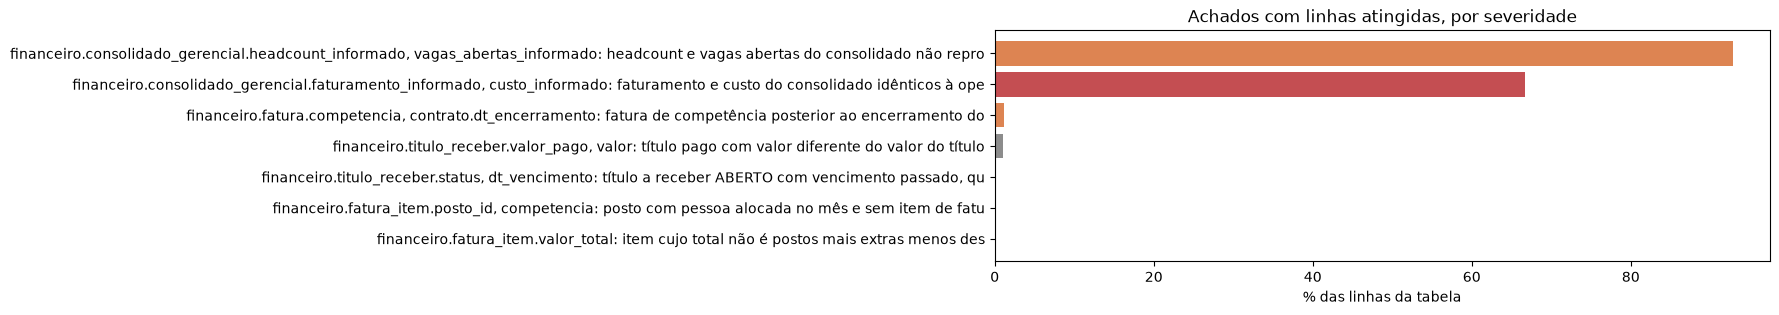

registro gravado em dados/auditoria/financeiro.json


In [20]:
com_linhas = quadro[quadro["linhas"] > 0].sort_values("pct")
if len(com_linhas):
    fig, eixo = plt.subplots(figsize=(10, max(3, 0.4 * len(com_linhas))))
    cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C", "nenhuma": "#4C72B0"}
    eixo.barh(com_linhas["tabela"] + "." + com_linhas["coluna"] + ": " + com_linhas["achado"].str.slice(0, 50), com_linhas["pct"], color=[cores[s] for s in com_linhas["severidade"]])
    eixo.set_xlabel("% das linhas da tabela")
    eixo.set_title("Achados com linhas atingidas, por severidade")
    plt.tight_layout()
    plt.show()
caminho = registro.salvar(REFERENCIA.isoformat())
print(f"registro gravado em {caminho.relative_to(RAIZ)}")
con.close()

## Nota Técnica de fechamento

**O que foi examinado:** as 10 tabelas do domínio `financeiro`, 93 colunas e 18.758 linhas vivas, na carga identificada na seção 2: tipo, completude e coerência, unicidade, domínios, a aritmética da fatura, do título e do imposto, datas e prazos, integridade referencial, e o consolidado gerencial contra a operação e contra a planilha.

**O veredicto: a operação financeira fecha, e o consolidado da gerência deixou de fechar com ela em 2022.** Fatura, título, imposto e prazo estão íntegros; o adicional de IRPJ e as faturas de honorário sem item são regra, não erro. O achado que importa é a declaração do cliente confirmada com data: faturamento e custo informados idênticos à operação até 2021 e divergentes desde janeiro de 2022, com a diferença chegando a 4,4% no faturamento de 2026 e 5,7% no custo de 2025 (alta); e o headcount informado sem definição reproduzível em nenhum ano (média). Em volta, 42 faturas de competência posterior ao encerramento do contrato (média) e quatro achados pequenos (baixas).

**Próximos passos:** `treinamento` e `sst`, e depois o fechamento, com as seis declarações confrontadas.